In [30]:
import numpy as np
import torch
import SimpleITK as sitk

mask = np.zeros((256, 256)).astype(np.int8)
center = (56, 56)
for i in range(center[0] - 5, center[0] + 5):
    for j in range(center[1] - 5, center[1] + 5):
        mask[i, j] = 1

center = (128, 128)
for i in range(center[0] - 5, center[0] + 5):
    for j in range(center[1] - 5, center[1] + 5):
        mask[i, j] = 1

mask = sitk.GetImageFromArray(mask)
threshold = 1

filter = sitk.ConnectedComponentImageFilter()
filter.SetFullyConnected(True)

mask_cc = filter.Execute(mask)
mask_binary_cc = sitk.RelabelComponent(mask_cc, threshold)
max_val = np.max(sitk.GetArrayFromImage(mask_binary_cc))
print(max_val)

2


In [41]:
import cv2
import numpy as np
from scipy.ndimage import label, center_of_mass

labeled_array, num_features = label(mask)

# Find the center of mass (centroid) of each component
centroids = center_of_mass(mask, labeled_array, range(1, num_features + 1))

# Calculate the size of each component
sizes = np.bincount(labeled_array.ravel())[1:]  # skip the background count


In [42]:
print(centroids, sizes)

[(55.5, 55.5), (127.5, 127.5)] [100 100]


In [38]:
print(labeled_array.shape, nu_features)

(256, 256) 2


In [31]:
print(mask_cc.GetSize(), mask_binary_cc.GetSize())

(256, 256) (256, 256)


[0 1 2] [0 1 2]
0


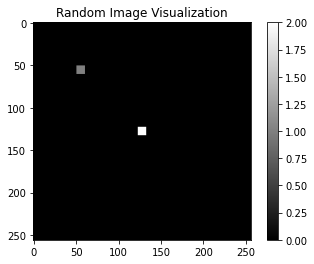

In [34]:
import matplotlib.pyplot as plt

mask = sitk.GetArrayFromImage(mask_cc)
mask_bin = sitk.GetArrayFromImage(mask_binary_cc)
print(np.unique(mask), np.unique(mask_bin))

print(np.sum(mask - mask_bin))

# Visualize the image
plt.imshow(mask_bin, cmap='gray')
plt.colorbar()
plt.title('Random Image Visualization')
plt.show()

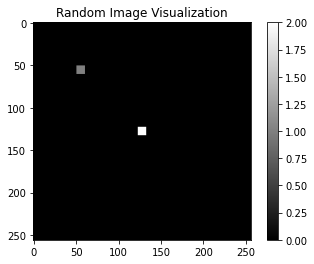

In [33]:
import matplotlib.pyplot as plt

# Visualize the image
plt.imshow(mask, cmap='gray')
plt.colorbar()
plt.title('Random Image Visualization')
plt.show()